In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mastu import HSV
import functions as fn
from scipy.optimize import curve_fit

%matplotlib widget

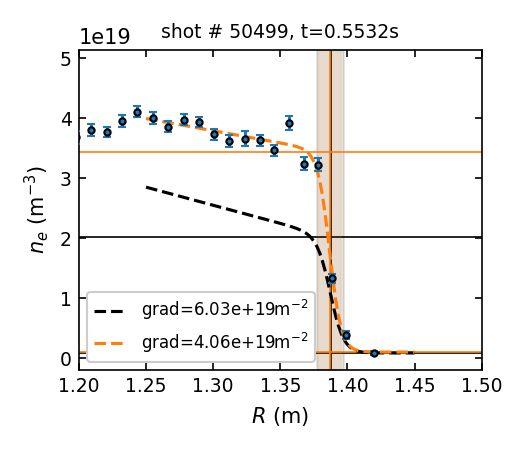

In [2]:
shotn = 50499
time, ne, neErr, Rthomson = HSV.getThomson(shotn, 'n_e')
_, R0, height, width, grad, bkgd = HSV.getPedestal(shotn, 'n_e')

t = fn.findNearest(time, 0.55)
r = fn.findNearest(Rthomson[t], 1.25)
R = np.linspace(1.25, 1.45, 100)
profile = HSV.mtanh(R, R0[t], height[t], width[t], grad[t], bkgd[t])

boo = np.isfinite(ne[t,r:])
x = Rthomson[t,r:][boo]
y = ne[t,r:][boo]
yErr = neErr[t,r:][boo]
popt, pcov = curve_fit(
    HSV.mtanh, x, y, sigma=yErr, absolute_sigma=True, 
    p0=(R0[t],height[t],width[t],grad[t],bkgd[t])
)
profile2 = HSV.mtanh(R, *popt)

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(Rthomson[t], ne[t], yerr=neErr[t], fmt='.', c='C0', mec='k', capsize=2, zorder=3)
ax.plot(R, profile, '--k', zorder=2, label=f'grad={grad[t]:.3g}m$^{{-2}}$')
ax.plot(R, profile2, '--', c='C1', zorder=2, label=f'grad={popt[-2]:.3g}m$^{{-2}}$')
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$n_e$ (m$^{-3}$)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_title(f'shot # {shotn}, t={time[t]:.4f}s', fontsize=9)

xlim = ax.get_xlim()
xlim = (1.2, 1.5)
ylim = ax.get_ylim()
ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.plot([R0[t], R0[t]], ylim, '-k', lw=0.8, zorder=1)
ax.plot(xlim, [height[t], height[t]], '-k', lw=0.8, zorder=1)
ax.plot(xlim, [bkgd[t], bkgd[t]], '-k', lw=0.8, zorder=1)
ax.fill_between(
    [R0[t]-width[t]/2.,R0[t]+width[t]/2.,], 
    [ylim[0],ylim[0]], [ylim[1],ylim[1]], color='k', alpha=0.1
)

ax.plot([popt[0], popt[0]], ylim, '-', c='C1', lw=0.8, zorder=1)
ax.plot(xlim, [popt[1], popt[1]], '-', c='C1', lw=0.8, zorder=1)
ax.plot(xlim, [popt[-1], popt[-1]], '-', c='C1', lw=0.8, zorder=1)
ax.fill_between(
    [popt[0]-popt[2]/2.,popt[0]+popt[2]/2.,], 
    [ylim[0],ylim[0]], [ylim[1],ylim[1]], color='C1', alpha=0.1
)

plt.tight_layout()

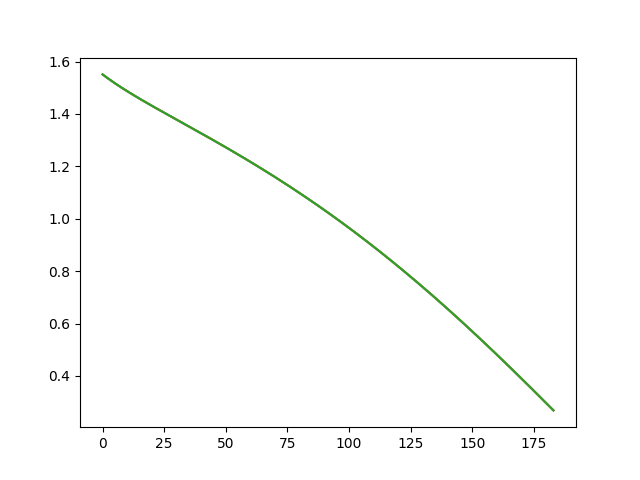

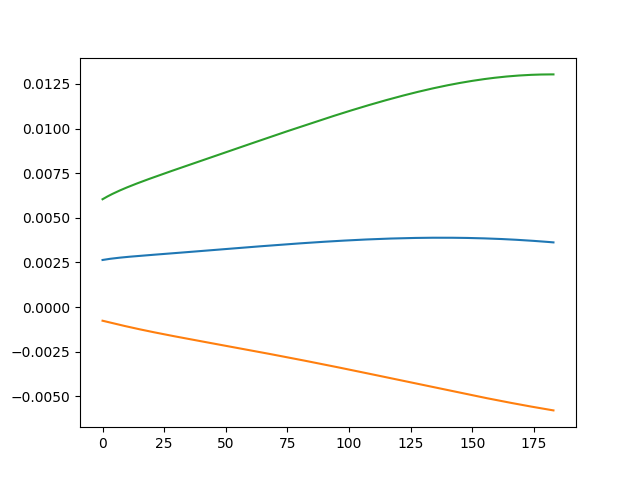

In [15]:
R0, z0 = HSV.getRz(
    "/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", 
    239, 240, 32, 216)
R1, z1 = HSV.getRz(
    "/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", 
    240, 241, 32, 216)
R2, z2 = HSV.getRz(
    "/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", 
    238, 239, 32, 216)

plt.figure()
plt.plot(R0)
plt.plot(R1)
plt.plot(R2)
plt.figure()
plt.plot(z0)
plt.plot(z1)
plt.plot(z2)

In [16]:
R0.max()

1.5508726296196582

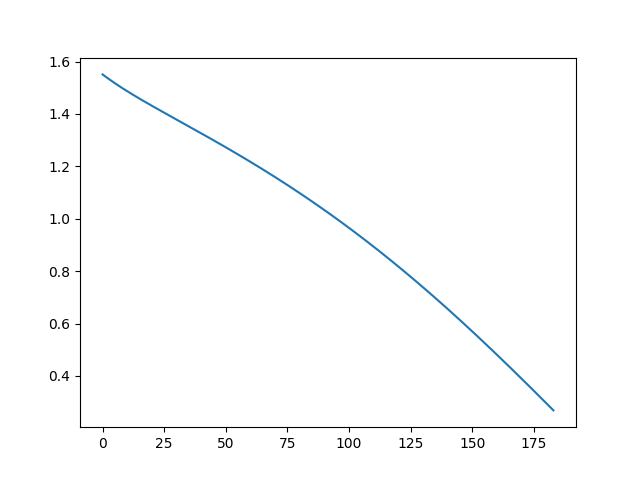

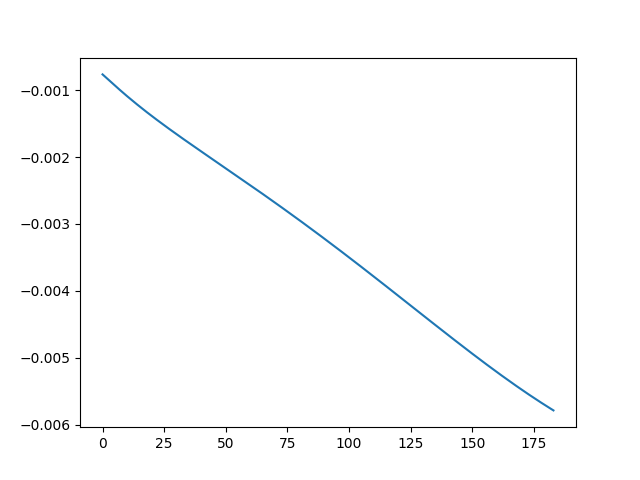

In [13]:
I0 = 240
I1 = I0 + 1
R0, z0 = HSV.getRz(
    "/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", 
    I0, I1, 32, 216)

plt.figure()
plt.plot(R0)
plt.figure()
plt.plot(z0)

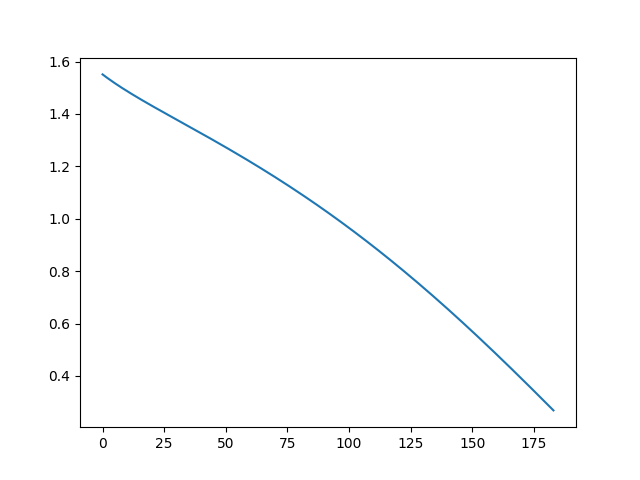

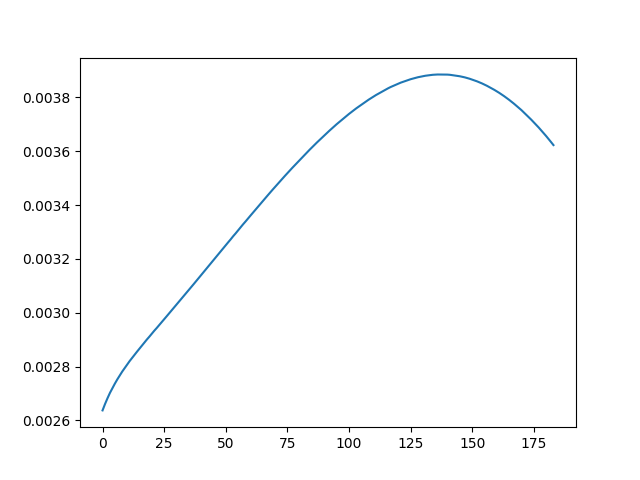

In [7]:
plt.figure()
plt.plot(R0)
plt.figure()
plt.plot(z0)